# Predict logP

The aim of this exercise is to compare model performance between a GNN and a supervised method to predict logP. 
Consider as a starting point one of the GNNs from session 14 (GCN, GIN, or GAT), and a supervised model of your choice (e.g., Random Forest with MACCS fingerprints).

#### Tasks:
1) Create a training and a test set
2) Build a supervised model of your choice on the training data and evaluate its performance on the test set
3) Build a GNN and compare its performance to the supervised model
4) Discuss the outcome


In [22]:
# complete imports if needed for your solution
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error


#for supervised model
from sklearn.ensemble import RandomForestRegressor


#for GNN
import torch
import torch.nn.functional as F
from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool


Load the data from Session 11

In [2]:
df = pd.read_csv(os.path.join("..", "..", "lectures", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])
df = df.loc[df.SMILES != 'C'] # remove the one compound containing only a single atom
df.head()

,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0


### Setting the stage
Split the data into training and test sets. The test set will be used to compare model performance.


In [9]:

# target = LogP
y = df["LogP"].values
X = df.drop(columns=["LogP", "SMILES"]).values

print(X.shape, y.shape)

(1127, 11) (1127,)


In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Baseline supervised model
Choose a 
   - regression model (RF, SVR, kNN, Gradient Boost, ...) 
   - molecular descriptor (RDKit, Mordred, ...) or fingerprint (MACCS, Morgan, RDKit, ...)
      
Build a feature matrix and target vector. Add scaling if needed for your model.
Train the model on the training set and apply it to the test set.
Calculate performance metrics (R2, RMSE) for model performance on the test set.

In [17]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))

print("Random Forest:")
print("R2 =", r2_rf)
print("RMSE =", rmse_rf)

Random Forest:
R2 = 0.912307356194661
RMSE = 0.563184324168176


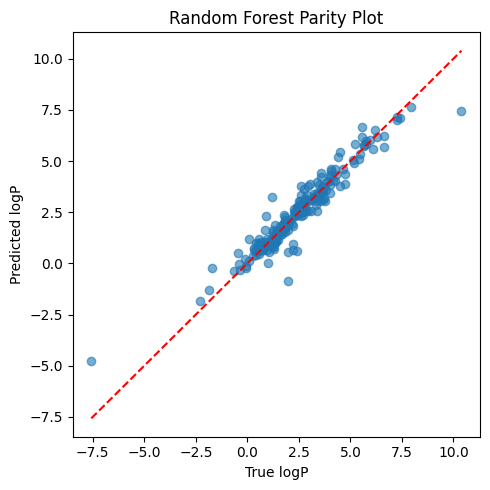

In [19]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("True logP")
plt.ylabel("Predicted logP")
plt.title("Random Forest Parity Plot")
plt.tight_layout()
plt.show()

### Unpervised GNN model
Choose a GNN architecture
   - GCN, GIN, or GAT
      
Transform input smiles to graph objects using the atom and bond features. Build graphs for both training and test set. Train the GNN on the training set. Adapt architecture and parameters until you are happy with the performance. Apply the trained model on the test set (once!) and calculate model performance metrics

In [23]:
def atom_features(atom):
    return torch.tensor([
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ], dtype=torch.float)

def bond_features(bond):
    bt = bond.GetBondType()
    return torch.tensor([
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing(),
    ], dtype=torch.float)

def smiles_to_graph(smiles, y):
    mol = Chem.MolFromSmiles(smiles)

    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()])

    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        edge_index.append([i, j])
        edge_index.append([j, i])

        bf = bond_features(bond)
        edge_attr.append(bf)
        edge_attr.append(bf)

    edge_index = torch.tensor(edge_index).t().contiguous()
    edge_attr = torch.stack(edge_attr)

    y = torch.tensor([y], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [24]:
graphs = [smiles_to_graph(row.SMILES, row.LogP) for _, row in df.iterrows()]

In [25]:
def create_splits(graphs, train_ratio=0.8, seed=42):
    torch.manual_seed(seed)
    perm = torch.randperm(len(graphs))
    graphs = [graphs[i] for i in perm]

    n_train = int(len(graphs) * train_ratio)

    train_graphs = graphs[:n_train]
    test_graphs  = graphs[n_train:]

    return train_graphs, test_graphs

train_graphs, test_graphs = create_splits(graphs)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_graphs, batch_size=32)

In [26]:
class GCNModel(torch.nn.Module):
    def __init__(self, dim_h=64):
        super().__init__()
        self.conv1 = GCNConv(5, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze(-1)

In [27]:
def train_gnn(model, loader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        losses = []

        for batch in loader:
            optimizer.zero_grad()
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        print(f"Epoch {epoch+1:02d} | Loss = {np.mean(losses):.4f}")

In [28]:
def evaluate_gnn(model, loader):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index, batch.batch)
            preds.append(pred.view(-1).cpu())
            trues.append(batch.y.view(-1).cpu())

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    r2 = r2_score(trues, preds)
    rmse = np.sqrt(mean_squared_error(trues, preds))

    return r2, rmse

In [29]:
gcn = GCNModel()

print("Training GCN: ")
train_gnn(gcn, train_loader, epochs=10)

r2_gnn, rmse_gnn = evaluate_gnn(gcn, test_loader)

print("GCN Performance: ")
print("R2 =", r2_gnn)
print("RMSE =", rmse_gnn)

Training GCN: 
Epoch 01 | Loss = 4.8314
Epoch 02 | Loss = 3.4677
Epoch 03 | Loss = 3.3406
Epoch 04 | Loss = 3.3346
Epoch 05 | Loss = 3.1838
Epoch 06 | Loss = 3.2375
Epoch 07 | Loss = 3.1203
Epoch 08 | Loss = 3.2323
Epoch 09 | Loss = 3.0612
Epoch 10 | Loss = 3.2063
GCN Performance: 
R2 = 0.100863516330719
RMSE = 1.7868809621790833


Comparison of unsupervised and GNN

In [32]:
print(f"Random Forest=>")
print("R2 =", r2_rf)
print("RMSE =", rmse_rf)
print(" ")
print(f"GCN=>")
print("R2 =", r2_gnn)
print("RMSE =", rmse_gnn)

Random Forest=>
R2 = 0.912307356194661
RMSE = 0.563184324168176
 
GCN=>
R2 = 0.100863516330719
RMSE = 1.7868809621790833


### Discussion points
1) Which model (supervised or unsupervised) performed better on the test set, and why?

The supervised method, Random Forest, performed much better than the GCN. It achieved R² = 0.91 and RMSE = 0.56, while the GCN achieved R² = 0.10 and RMSE = 1.79. Also on the Random Forest parity plot it is visible that the model is capturing the relationship between features and logP very well.
The reason is that the Random Forest already uses molecular descriptors, which already encode chemical information that is relevant for logP, while the GCN has to learn relationships from scratch.


2) What did you try to improve model performance of your GNN? What did work, what did not work?

- 2-layer GCN architecture, ReLU activation functions, global mean pooling, ADam optimizer, training over multiple epochs

=> addidng a second GCN helped improved stability

wheras increasing training epochs, small changes in hidden dimension size did not help much.

3) Which challenges did you face in the process of building the models?

In general, the Random Forest model was easier to implement since it requires less code and we have used similar approaches multiple times in the course.
The main challenge in this assignment was setting up and using torch_geometric for the GNN. Initially, I had installation issues due to an outdated pip and dependency mismatches, which took some time to resolve.
After resolving the setup, the main difficulty was achieving good performance with the GNN compared to the Random Forest. The GNN required more effort in terms of tuning and training stability, while the Random Forest was more straightforward and gave more consistent results.

4) Which of your two models would you recommend to a chemist for predicting logP, and why?

In this case, I would recommend to use Random Forest model since it performs better on this dataset and is more stable and easier to trian. 
The GCN is more flexible in theory, but in this case the classical approach is more suitable.